In [1]:
#@title Estilo de la clase (ejecutar, no hace falta leer) {display-mode: "form"}
from IPython.display import HTML, display
display(HTML(r"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Work+Sans:wght@400;600&family=Amiri:wght@400;700&display=swap');
.rendered_html, .markdown, .cell .text_cell_render { font-family:'Work Sans',system-ui,sans-serif; color:#122535; }
.rendered_html h1,.rendered_html h2,.rendered_html h3 { font-family:'Amiri',Georgia,serif; color:#00529B; }
.rendered_html h2 { border-bottom:2px solid #00529B; padding-bottom:.2em; }
.rendered_html a { color:#00529B; }
.rendered_html table th { background:#00529B; color:#fff; }
.rendered_html h1,.rendered_html h2,.rendered_html h3 { scroll-margin-top:16px; }
</style>
"""))

# Clase 6 · Clasificación: regresión logística

**Analítica de Datos** · Maestría en Ciencias del Comportamiento · Universidad de San Andrés

**12/09/2026**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tomdamelio/analitica_de_datos_alumnos/blob/main/clases/clase-06/notebooks/clase06_python.ipynb)

---

La pregunta sigue siendo **¿quién va a renunciar en Nimbus?**, pero el modelo cambia. En vez
de mirar a los vecinos (KNN, Clase 4), hoy ajustamos una **regresión logística**. Esta es la misma
recta de la Clase 5, pero ahora va a predecir una probabilidad. No hace falta
escribir nada. alcanza con correr las celdas y mirar los números, que son exactamente los de
las slides.

Las dos ideas que queremos ver:

> **La regresión logística devuelve una probabilidad**, no una categoría (por ejemplo, sí o un no). Clasificar es un paso
> más, con una regla (el **umbral**) que elegimos nosotros.

> **La exactitud sola miente.** Un clasificador comete dos errores distintos, y hay que mirarlos
> por separado.

El recorrido tiene cinco pasos:

| # | Paso | Qué hacemos |
|---|---|---|
| 1 | Armar la tabla | unir las tablas de Nimbus y calcular los minutos con la cámara **apagada** |
| 2 | Partir | entrenamiento y testeo, la misma línea de la Clase 4 |
| 3 | Ajustar y leer la tabla | la S, y la tabla de coeficientes con `statsmodels` |
| 4 | Predecir | la cuenta a mano para un empleado nuevo, y `predict` |
| 5 | Evaluar | matriz de confusión, umbral, sensibilidad y especificidad, precisión y F1, ROC y AUC |

> **Cómo se usa esta notebook.** Las celdas de código se corren con `Shift+Enter`, de arriba
> hacia abajo. Si te salteás una, las de abajo pueden fallar porque dependen de variables
> definidas antes.

## 1. Armar la tabla

<a id="sec-cargar"></a>

Las mismas tres tablas de la Clase 4, unidas por `empleado_id`.
Los datos **se leen por URL**, no hay que bajar ni montar nada.

El procesamiento es el mismo. Filtramos por el año 2025 y unimos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

SEED = 42

BASE = "https://raw.githubusercontent.com/tomdamelio/analitica_de_datos_alumnos/main/data/toy-nimbus/"
if os.path.isdir("../../../data/toy-nimbus"):
    BASE = "../../../data/toy-nimbus/"

empleados = pd.read_csv(BASE + "nimbus_empleados.csv")
salario   = pd.read_csv(BASE + "nimbus_salario.csv")
rrhh      = pd.read_csv(BASE + "nimbus_rrhh.csv")

salario_2025 = salario[salario["anio"] == 2025].drop(columns="anio")
datos = empleados.merge(salario_2025, on="empleado_id").merge(rrhh, on="empleado_id")

print("la tabla unida:", datos.shape)
datos.head()

la tabla unida: (600, 13)


,empleado_id,sede,area,genero,educacion_nivel,antiguedad_anios,grupo_fruta,edad,salario_mensual,faltas_mes,weeklys_perdidas,minutos_camara_weekly,renuncia
0,1,Buenos Aires,Ventas,Masculino,Universitario,8,Tratamiento,47,1301000.0,3,0,45.0,No
1,2,Mar del Plata,Ingenieria,Femenino,Posgrado,8,Control,46,1329000.0,1,3,35.6,No
2,3,Mendoza,Producto,Femenino,Universitario,4,Tratamiento,31,1255000.0,1,2,31.7,No
3,4,Rosario,Producto,Masculino,Universitario,1,Tratamiento,54,1308000.0,0,4,30.4,No
4,5,Rosario,Operaciones,Masculino,Posgrado,3,Tratamiento,50,1471000.0,0,4,45.0,No


### La variable de hoy: minutos con la cámara apagada

La tabla trae `minutos_camara_weekly`, los minutos con la cámara **prendida** en la reunión
semanal, que dura 45 minutos. En la clase usamos el complemento, los minutos con la cámara
**apagada**. Esto es más fácil para relacionar con la varible de renuncia, porque la relación va para arriba (más cámara apagada, más
renuncia). Es una transformación, pero nada más. La información es la misma.

Nuestra segunda columna, `renuncia`, viene como texto (`Si` / `No`), pero la regresión logística
necesita un **0 o un 1**. Fijate abajo: `(datos["renuncia"] == "Si")` pregunta fila por fila si renunció y
devuelve `True` / `False`. Después, `.astype(int)` convierte eso en `1` / `0`.

In [3]:
datos["camara_apagada"] = 45 - datos["minutos_camara_weekly"]
datos["y"] = (datos["renuncia"] == "Si").astype(int)

print("cámara apagada: de", datos["camara_apagada"].min(), "a", datos["camara_apagada"].max(), "minutos")
print("renunciaron:", datos["y"].sum(), "de", len(datos), f"({datos['y'].mean():.1%})")
datos[["empleado_id", "minutos_camara_weekly", "camara_apagada", "renuncia", "y"]].head()

cámara apagada: de 0.0 a 35.7 minutos
renunciaron: 102 de 600 (17.0%)


,empleado_id,minutos_camara_weekly,camara_apagada,renuncia,y
0,1,45.0,0.0,No,0
1,2,35.6,9.4,No,0
2,3,31.7,13.3,No,0
3,4,30.4,14.6,No,0
4,5,45.0,0.0,No,0


Ese 17 % es nuestro número baseline. ¿Te acordás de la clase 4? Un modelo que no mire nada y
diga "no renuncia nadie" acierta el 83 %, y ese es el **piso** contra el que se compara cualquier
clasificador.

## 2. Partir

<a id="sec-partir"></a>

Igual que en la Clase 4: el 70 % para **entrenar** y el 30 % para **evaluar** con datos que el
modelo nunca vio, estratificado (misma proporción de renuncias en las dos partes) y con la
misma semilla. Con `SEED = 42` los 420 y los 180 empleados son exactamente los de las slides.

Hoy el predictor es uno solo, `camara_apagada`. Los corchetes dobles en `X` son para que
quede como una tabla de una columna y no como una lista suelta. Es el tipo de datos que esperan
`train_test_split` y los modelos.

In [4]:
from sklearn.model_selection import train_test_split

X = datos[["camara_apagada"]]   # lo que el modelo puede mirar
y = datos["y"]                   # lo que tiene que adivinar: 1 renunció, 0 se quedó

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=SEED)

print("entrenamiento:", len(X_train), "empleados, de los cuales renunciaron", y_train.sum())
print("testeo:       ", len(X_test), "empleados, de los cuales renunciaron", y_test.sum())

entrenamiento: 420 empleados, de los cuales renunciaron 71
testeo:        180 empleados, de los cuales renunciaron 31


## 3. Ajustar la S y leer la tabla

<a id="sec-logistica"></a>

Para ajustar usamos `statsmodels`, la misma librería de la Clase 5, porque devuelve **la
tabla de coeficientes completa** (coeficiente, error estándar, z, p-valor). La receta es la de la regresión lineal con dos cambios:

- `sm.add_constant(X_train)` agrega la columna de unos para así poder ajustar el intercepto β₀, igual
  que en la Clase 5.
- `sm.Logit(...)` en vez de `sm.OLS(...)`: le decimos que la respuesta es 0/1 y que queremos la
  S. Por dentro, en vez de mínimos cuadrados, busca los β por **máxima verosimilitud**, los β en log(odds) que hacen **más probable** lo que efectivamente pasó.

`.fit()` ajusta; `disp=0` solo le pide que no imprima el detalle de la búsqueda.

In [5]:
import statsmodels.api as sm

X_train_c = sm.add_constant(X_train)          # la columna de unos para el intercepto
modelo = sm.Logit(y_train, X_train_c).fit(disp=0)

b0 = modelo.params["const"]
b1 = modelo.params["camara_apagada"]
print(f"log(odds de renunciar) = {b0:.3f} + {b1:.3f} · minutos con cámara apagada")

log(odds de renunciar) = -8.329 + 0.422 · minutos con cámara apagada


Los dos números de las slides: **β₀ = −8,33** y **β₁ = +0,42**. Están en la escala de
**log(odds)**, no de probabilidad:

- β₀ es el log(odds) de renunciar con 0 minutos de cámara apagada (alguien que la tiene
  prendida toda la weekly). Es muy negativo, los odds están muy en contra.
- β₁ dice que **cada minuto más** con la cámara apagada suma 0,42 al log(odds). Siempre lo
  mismo, porque en "escala" log(odds) se ve una recta. En odds, cada minuto multiplica por
  e^0,42 = 1,52: los odds de renunciar suben un 52 % por minuto.

Y la tabla completa, la misma que la Clase 5 con `z` en vez de `t`:

In [6]:
tabla = pd.DataFrame({
    "coef.": modelo.params,
    "error est.": modelo.bse,
    "z": modelo.tvalues,
    "p-valor": modelo.pvalues,
}).round(4)
tabla

,coef.,error est.,z,p-valor
const,-8.3286,0.8823,-9.4399,0.0
camara_apagada,0.4217,0.0482,8.7434,0.0


Cómo se lee, columna por columna, igual que la semana pasada:

- **coef.**: β₀ y β₁, en log(odds).
- **error est.**: la incertidumbre de cada coeficiente.
- **z = coef. / error est.**: cuántos errores estándar está el coeficiente lejos de cero. Es
  el `t` de la regresión lineal con otro nombre.
- **p-valor**: si β₁ fuera cero (la cámara no importa), ¿qué tan raro sería ver un z de 8,7?
  Prácticamente imposible. La variable importa.

Para verlo, la S ajustada sobre los 420 empleados de entrenamiento. La curva sale de la
fórmula con los dos β:

$$p(x) = \frac{e^{\beta_0 + \beta_1 x}}{1 + e^{\beta_0 + \beta_1 x}}$$

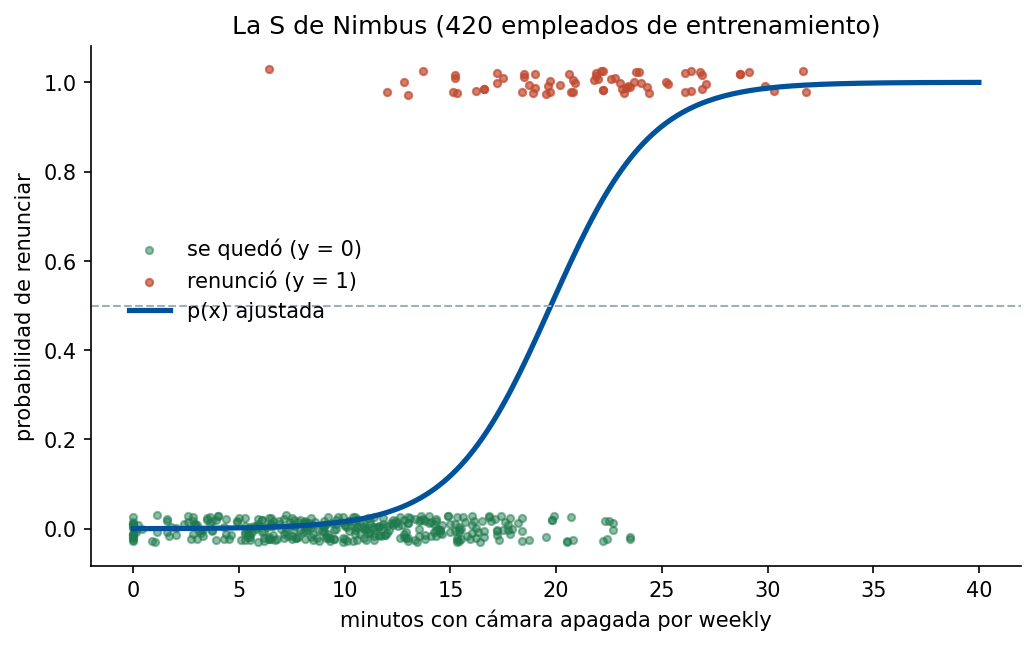

In [7]:
#@title La figura (solo ejecutar; el código del gráfico no es el tema de hoy) {display-mode: "form"}
NAVY, TERRACOTA, VERDE, GRIS = "#00529B", "#C0492F", "#1F7A4D", "#9FB0BD"

grilla = np.linspace(0, 40, 200)
p_grilla = 1 / (1 + np.exp(-(b0 + b1 * grilla)))

rng = np.random.default_rng(SEED)
salto = rng.uniform(-0.03, 0.03, size=len(X_train))   # un poco de ruido vertical para que se vean los puntos

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.scatter(X_train["camara_apagada"][y_train == 0], 0 + salto[y_train.values == 0], s=12, color=VERDE, alpha=0.5, label="se quedó (y = 0)")
ax.scatter(X_train["camara_apagada"][y_train == 1], 1 + salto[y_train.values == 1], s=12, color=TERRACOTA, alpha=0.7, label="renunció (y = 1)")
ax.plot(grilla, p_grilla, color=NAVY, linewidth=2.5, label="p(x) ajustada")
ax.axhline(0.5, color=GRIS, linestyle="--", linewidth=1)
ax.set_xlabel("minutos con cámara apagada por weekly")
ax.set_ylabel("probabilidad de renunciar")
ax.set_title("La S de Nimbus (420 empleados de entrenamiento)")
ax.legend(loc="center left", bbox_to_anchor=(0.02, 0.55), frameon=False)
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
try:   # guarda la figura para la página de la clase; en Colab no hay carpeta y se saltea
    os.makedirs("../assets/figures", exist_ok=True)
    fig.savefig("../assets/figures/clase06_curva_s.png", bbox_inches="tight")
except OSError:
    pass
plt.show()

## 4. Predecir para un empleado nuevo

<a id="sec-predecir"></a>

Con los dos β se puede predecir para cualquiera. La cuenta de las slides para el empleado
**B** son tres pasos, y cada uno usa el resultado del
anterior:

1. **log(odds)**: colocar el nuevo `x` (25) en la recta, β₀ + β₁.
2. **odds**: deshacer el logaritmo, e elevado a eso.
3. **probabilidad**: odds / (1 + odds).

`np.exp` es "e elevado a". Abajo, la misma cuenta con `modelo.predict`, que hace los tres pasos
de una vez: los dos resultados tienen que coincidir.

In [8]:
x = 25

log_odds = b0 + b1 * x                # 1. la recta
odds = np.exp(log_odds)               # 2. deshacer el logaritmo
p = odds / (1 + odds)                 # 3. de odds a probabilidad

print(f"log(odds) = {b0:.2f} + {b1:.3f} · {x} = {log_odds:.2f}")
print(f"odds      = e^{log_odds:.2f} = {odds:.2f}")
print(f"p         = {odds:.2f} / (1 + {odds:.2f}) = {p:.3f}")

# La misma cuenta, hecha por el modelo (la tabla de una fila necesita también la columna de unos)
nuevo = pd.DataFrame({"const": [1.0], "camara_apagada": [x]})
p_modelo = modelo.predict(nuevo)[0]
print()
print(f"a mano:          {p:.3f}")
print(f"modelo.predict:  {p_modelo:.3f}")

log(odds) = -8.33 + 0.422 · 25 = 2.21
odds      = e^2.21 = 9.15
p         = 9.15 / (1 + 9.15) = 0.901

a mano:          0.901
modelo.predict:  0.901


Un 90 % de probabilidad de renunciar. Con el umbral de 0,5 lo clasificaríamos como
"renuncia". Con 15 minutos en vez de 25 la misma cuenta da 0,12, "se queda" (¡podes probarlo!).

## 5. Evaluar

<a id="sec-evaluar"></a>

Todo lo que sigue se mide sobre los **180 empleados de testeo**, los que el modelo no vio.
Primero la probabilidad que el modelo le asigna a cada uno, y después la regla por defecto:
probabilidad mayor que 0,5, "renuncia".

`(p_test > umbral)` devuelve `True` / `False` para cada empleado, y `.astype(int)` lo pasa a
`1` / `0`, la misma codificación que `y_test`.

In [9]:
X_test_c = sm.add_constant(X_test)
p_test = modelo.predict(X_test_c)         # una probabilidad por empleado de testeo

umbral = 0.5
pred_05 = (p_test > umbral).astype(int)   # 1 si el modelo dice "renuncia"

print("primeros cinco empleados de testeo:")
print(pd.DataFrame({"cámara apagada": X_test["camara_apagada"].values[:5],
                    "probabilidad": p_test.values[:5].round(3),
                    "predicción": pred_05.values[:5],
                    "verdad": y_test.values[:5]}))

primeros cinco empleados de testeo:
   cámara apagada  probabilidad  predicción  verdad
0             8.6         0.009           0       0
1             4.8         0.002           0       0
2             5.7         0.003           0       0
3             6.5         0.004           0       0
4            18.2         0.342           0       0


### 5.1 La matriz de confusión y la exactitud

Para los resultados del conjunto de prueba, vamos a cruzar lo que el modelo predijo con lo que pasó de verdad. En este caso, la matriz resultante va a tener cuatro casilleros.
`confusion_matrix` cuenta los casos. Nosotros los desarmamos con nombre para interpretarlos más fácil. El orden que devuelve scikit-learn es:
- Las filas son la verdad: Primera fila 0 (se queda), segunda fila 1 (renuncia)
- Las columnas son la predicción: Mismos índices.

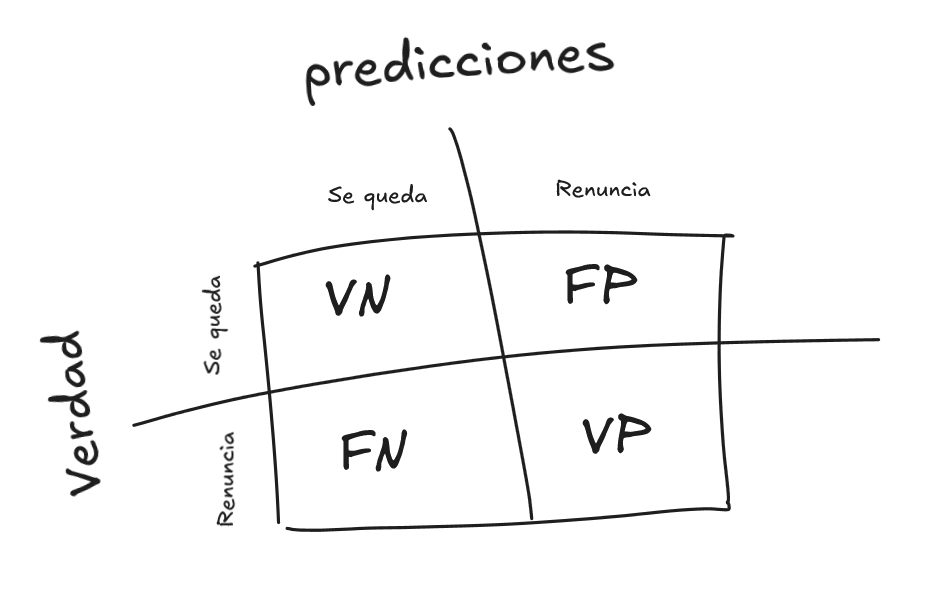

In [10]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, pred_05)
VN, FP, FN, VP = matriz.ravel()   # .ravel() aplana la matriz 2x2 en cuatro números, en este orden

print("verdaderos positivos (VP): predijo renuncia y renunció:", VP)
print("falsos negativos     (FN): predijo se queda y renunció:", FN)
print("falsos positivos     (FP): predijo renuncia y se quedó:", FP)
print("verdaderos negativos (VN): predijo se queda y se quedó:", VN)
print()
print(pd.DataFrame(matriz,
                   index=["verdad: se quedó", "verdad: renunció"],
                   columns=["predice: se queda", "predice: renuncia"]))

verdaderos positivos (VP): predijo renuncia y renunció: 18
falsos negativos     (FN): predijo se queda y renunció: 13
falsos positivos     (FP): predijo renuncia y se quedó: 10
verdaderos negativos (VN): predijo se queda y se quedó: 139

                  predice: se queda  predice: renuncia
verdad: se quedó                139                 10
verdad: renunció                 13                 18


Los mismos 18, 13, 10 y 139 de las slides. La **exactitud** (*accuracy* en inglés) es la diagonal sobre el total.
Y para saber si es buena, se compara con el piso de la sección 1: el 83 % de un "modelo" que
diga que nadie renuncia.

In [11]:
exactitud = (VP + VN) / (VP + VN + FP + FN)
piso = 1 - y_test.mean()               # la proporción de "se quedó" en testeo

print(f"exactitud del modelo:            {exactitud:.1%}")
print(f"piso:                            {piso:.1%}")
print(f"lo que el modelo aporta:         {exactitud - piso:+.1%}")

exactitud del modelo:            87.2%
piso:                            82.8%
lo que el modelo aporta:         +4.4%


### 5.2 Dos errores, dos números

La exactitud mezcla los dos errores: Cuando el modelo se equivoca en los positivos, y cuando se equivoca en los negativos.**Sensibilidad** y **especificidad** los separan, cada una
mirando una columna de la matriz:

- **Sensibilidad** = VP / (VP + FN): de los que **realmente renunciaron**, ¿qué fracción predijo como
  "renuncia"?
- **Especificidad** = VN / (VN + FP): de los que **realmente se quedaron**, ¿qué fracción predijo como
  "se queda"?

In [12]:
sensibilidad = VP / (VP + FN)
especificidad = VN / (VN + FP)

print(f"sensibilidad:   {VP} / {VP + FN} = {sensibilidad:.1%}   (los otros {FN} son falsos negativos)")
print(f"especificidad:  {VN} / {VN + FP} = {especificidad:.1%}   (los otros {FP} son falsos positivos)")

sensibilidad:   18 / 31 = 58.1%   (los otros 13 son falsos negativos)
especificidad:  139 / 149 = 93.3%   (los otros 10 son falsos positivos)


Ahí está lo que la exactitud escondía: el modelo acierta el 87 % en total, pero **de los que
se van, detecta poco más de la mitad**. Si RRHH quería llegar antes de la renuncia, con este
umbral llega a 18 de 31.

### 5.3 El umbral es una perilla

El 0,5 que venimos usando no tiene nada de especial. Es lo que usa el software si no le decimos nada.

Bajarlo hace que el modelo
prediga "renuncia" para más gente. Ahí suben los verdaderos positivos (y la sensibilidad) a costa
de más falsos positivos (baja la especificidad). Para verlo, hacemos la misma cuenta con tres umbrales,
en una función chica que repite los pasos de arriba.

Fijense que no hace falta ni siquiera volver a entrenar el modelo. Las predicciones en términos de probabilidad ya las tenemos.

In [18]:
def metricas(umbral):
    pred = (p_test > umbral).astype(int)
    VN, FP, FN, VP = confusion_matrix(y_test, pred).ravel()
    return {"umbral": umbral,
            "VP": VP, "FN": FN, "FP": FP, "VN": VN,
            "exactitud": (VP + VN) / len(pred),
            "sensibilidad": VP / (VP + FN),
            "especificidad": VN / (VN + FP)}

filas = []
for u in [0.5, 0.3, 0.2]:
    filas.append(metricas(u))

pd.DataFrame(filas).set_index("umbral").round(3)

,VP,FN,FP,VN,exactitud,sensibilidad,especificidad
umbral,,,,,,,
0.5,18,13,10,139,0.872,0.581,0.933
0.3,24,7,17,132,0.867,0.774,0.886
0.2,26,5,20,129,0.861,0.839,0.866


Con el umbral en 0,2 la sensibilidad salta de 58 % a 84 % (26 de los 31 que renunciaron), la
especificidad baja de 93 % a 87 % (veinte falsos positivos en vez de diez), y la exactitud
apenas se mueve.

**No hay un umbral correcto**. Esto es parte de modelar: hay un reparto de errores que **elegimos** según qué error cuesta más.

### 5.4 Todos los umbrales a la vez: la curva ROC y la AUC

En vez de una matriz por umbral, un solo dibujo con todos: para cada umbral entre 1 y 0, un
punto con la tasa de falsos positivos (1 − especificidad) en el eje horizontal y la
sensibilidad en el vertical. `roc_curve` recorre los umbrales por nosotros, y `roc_auc_score`
calcula el área bajo esa curva. Si el área fuera **1**, sería un clasificador perfecto. **0,5** es como tirar una moneda.

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, umbrales = roc_curve(y_test, p_test)
auc = roc_auc_score(y_test, p_test)
print(f"AUC del modelo con cámara apagada: {auc:.3f}")

AUC del modelo con cámara apagada: 0.904


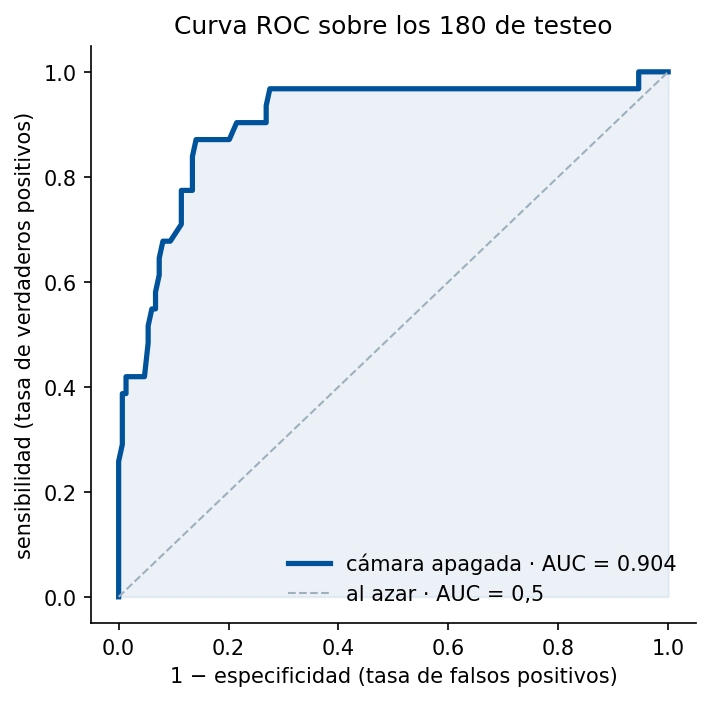

In [16]:
#@title La figura (solo ejecutar) {display-mode: "form"}
fig, ax = plt.subplots(figsize=(5.2, 5), dpi=150)
ax.plot(fpr, tpr, color=NAVY, linewidth=2.5, label=f"cámara apagada · AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], color=GRIS, linestyle="--", linewidth=1, label="al azar · AUC = 0,5")
ax.fill_between(fpr, tpr, color=NAVY, alpha=0.08)
ax.set_xlabel("1 − especificidad (tasa de falsos positivos)")
ax.set_ylabel("sensibilidad (tasa de verdaderos positivos)")
ax.set_title("Curva ROC sobre los 180 de testeo")
ax.legend(loc="lower right", frameon=False)
for lado in ["top", "right"]:
    ax.spines[lado].set_visible(False)
try:
    fig.savefig("../assets/figures/clase06_roc.png", bbox_inches="tight")
except OSError:
    pass
plt.show()

### 5.6 La AUC sirve para comparar modelos

Para qué sirve la AUC, concretamente: para comparar clasificadores **sin fijar un umbral**.
Un segundo modelo con las tres señales de comportamiento juntas (faltas, weeklys perdidas y
cámara apagada), ajustado sobre los mismos 420 y evaluado sobre los mismos 180. Los mismos
pasos que antes, con tres columnas en vez de una.

In [17]:
senales = ["faltas_mes", "weeklys_perdidas", "camara_apagada"]

X3_train = sm.add_constant(datos.loc[X_train.index, senales])
X3_test = sm.add_constant(datos.loc[X_test.index, senales])

modelo_3 = sm.Logit(y_train, X3_train).fit(disp=0)
p3_test = modelo_3.predict(X3_test)
auc_3 = roc_auc_score(y_test, p3_test)

print(f"AUC con cámara apagada sola:       {auc:.3f}")
print(f"AUC con las tres señales juntas:   {auc_3:.3f}")
print()
print(pd.DataFrame({"coef.": modelo_3.params, "p-valor": modelo_3.pvalues}).round(4))

AUC con cámara apagada sola:       0.904
AUC con las tres señales juntas:   0.933

                   coef.  p-valor
const            -8.8284   0.0000
faltas_mes        0.3659   0.0136
weeklys_perdidas  0.5684   0.0000
camara_apagada    0.3215   0.0000


Tres señales predicen mejor que una (0,93 contra 0,90), y las tres son significativas. Fíjense
que el coeficiente de la cámara apagada bajó de 0,42 a 0,32. **Un β se lee según con qué otros β
esté**, porque parte de lo que explicaba solo ahora lo explican las faltas. Esa es la idea del
último bloque de la clase.

## Para cerrar

Lo que hicimos, en el orden de la clase:

1. Ajustamos una regresión logística, y leímos β₀ y β₁ en la escala de log(odds).
2. Predijimos para un empleado nuevo a mano, en tres pasos: recta, e elevado, odds a
   probabilidad. `predict` da lo mismo.
3. Evaluamos sobre testeo: la matriz de confusión, la exactitud contra el piso, sensibilidad y
   especificidad, el umbral como perilla, precisión y F1, y la ROC con su AUC.
4. Comparamos dos modelos con la AUC, sin fijar ningún umbral.

## Vocabulario de hoy

| Palabra | Qué significa | Dónde apareció en el código |
|---|---|---|
| **log(odds)** | la escala en la que la logística es una recta | `b0 + b1 * minutos` |
| **odds** | p / (1 − p): a favor sobre en contra | `np.exp(log_odds)` |
| **Máxima verosimilitud** | el criterio con el que se eligen los β | `sm.Logit(...).fit()` |
| **z** | coef. / error est., el `t` de la Clase 5 | `modelo.tvalues` |
| **Umbral** | la probabilidad a partir de la cual se predice "renuncia" | `p_test > umbral` |
| **Matriz de confusión** | VP, FP, FN, VN | `confusion_matrix` |
| **Exactitud** | (VP + VN) / total | `exactitud` |
| **Sensibilidad (recall)** | VP / (VP + FN) | `sensibilidad` |
| **Especificidad** | VN / (VN + FP) | `especificidad` |
| **Precisión** | VP / (VP + FP) | `precision` |
| **F1** | media armónica de precisión y recall | `f1` |
| **Curva ROC** | sensibilidad contra 1 − especificidad, para todos los umbrales | `roc_curve` |
| **AUC** | el área bajo la ROC: 1 perfecto, 0,5 azar | `roc_auc_score` |